# Retrained TransE

In [1]:
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pickle
import torch.nn as nn
import torch.optim as optim
import random
from torch.utils.data import Dataset, DataLoader
import re

Add the location of your preprocessed files below

In [2]:
csv_file = '../preprocess/'
topk = 2

Import CPE

In [3]:
df_cpe = pd.read_csv(csv_file + "csv_file/2021aug/cpe_ignore_version.csv", usecols=['part','vendor',
                'product', 'target_sw','target_hw','name','size']).sort_values(
                'size', ascending=False)

Import CVE

In [4]:
df_cve = pd.read_csv(csv_file + "csv_file/2021aug/cve/cve-2002.csv")
df_cve = df_cve.astype('object').fillna('*')
df_list = [df_cve]
for i in range(2003, 2022):
    filename = f'{csv_file}csv_file/2021aug/cve/cve-{i}.csv'
    df_temp = pd.read_csv(filename)
    df_temp = df_temp.astype('object').fillna('*')
    df_list.append(df_temp)
df_cve = pd.concat(df_list, ignore_index=True)


Import CWE

In [5]:
df_cwe = pd.read_csv(csv_file + "csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv(csv_file + "csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv(csv_file + "csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

,ID,Name,Type,Status,Has_Member
0,CWE-1000,"""Research Concepts""",Graph,Draft,CWE-284;CWE-435;CWE-664;CWE-682;CWE-691;CWE-69...
1,CWE-1003,"""Weaknesses for Simplified Mapping of Publishe...",Graph,Incomplete,CWE-20;CWE-74;CWE-116;CWE-119;CWE-200;CWE-269;...
2,CWE-1008,"""Architectural Concepts""",Graph,Incomplete,CWE-1009;CWE-1010;CWE-1011;CWE-1012;CWE-1013;C...
3,CWE-1026,"""Weaknesses in OWASP Top Ten (2017)""",Graph,Incomplete,CWE-1027;CWE-1028;CWE-1029;CWE-1030;CWE-1031;C...
4,CWE-1040,"""Quality Weaknesses with Indirect Security Imp...",Implicit,Incomplete,*
5,CWE-1081,"""Entries with Maintenance Notes""",Implicit,Draft,*
6,CWE-1128,"""CISQ Quality Measures (2016)""",Graph,Incomplete,CWE-1129;CWE-1130;CWE-1131;CWE-1132
7,CWE-1133,"""Weaknesses Addressed by the SEI CERT Oracle C...",Graph,Stable,CWE-1134;CWE-1135;CWE-1136;CWE-1137;CWE-1138;C...
8,CWE-1154,"""Weaknesses Addressed by the SEI CERT C Coding...",Graph,Stable,CWE-1155;CWE-1156;CWE-1157;CWE-1158;CWE-1159;C...
9,CWE-1178,"""Weaknesses Addressed by the SEI CERT Perl Cod...",Graph,Stable,CWE-1179;CWE-1180;CWE-1181;CWE-1182;CWE-1183;C...


In [6]:
print("The size of df_cpe, df_cve, df_cwe are:", df_cpe.shape[0], df_cve.shape[0], df_cwe.shape[0])

The size of df_cpe, df_cve, df_cwe are: 68338 167542 918


In [7]:
cwe_disc = ["CWE-119", "CWE-20", "CWE-200", "CWE-269", "CWE-287",
            "CWE-311", "CWE-330", "CWE-345", "CWE-400", "CWE-610",
            "CWE-662", "CWE-665", "CWE-668", "CWE-682", "CWE-697",
            "CWE-74", "CWE-755", "CWE-834"]
cwe_prohibited = df_cwe_cate["ID"].tolist() + df_cwe_view["ID"].tolist()

In [8]:
cwe_list = []

kg_cwe = []

for i, r in df_cwe.iterrows():
    cweid = r['ID']

    cwe_list.append(cweid)

    if (r['Related_Weakness'] != '*'):
        relatedlist = r['Related_Weakness'].split(';')
        for re in relatedlist:
            relation, other = re.split(':')
            other = 'CWE-' + other
            kg_cwe.append(([cweid, relation, other]))

    if (r['Language'] != '*'):
        langlist = r['Language'].split(';')
        for l in langlist:
            if (l != 'Language-Independent'):
                kg_cwe.append(([cweid, 'Language', l]))

    if (r['Technology'] != '*'):
        techlist = r['Technology'].split(';')
        for t in techlist:
            if (t != 'Technology-Independent'):
                kg_cwe.append(([cweid, 'Technology', t]))

    if (r['Likelihood_Of_Exploit'] != '*'):
        kg_cwe.append(([cweid, 'LikelihoodOfExploit', \
                        r['Likelihood_Of_Exploit']]))

    if (r['Consequence'] != '*'):
        conseqlist = r['Consequence'].split(';')
        for c in conseqlist:
            if (c != 'Other'):
                kg_cwe.append(([cweid, 'Consequence', c]))

In [9]:
kg_cate = []
kg_view = []

for i, r in df_cwe_cate.iterrows():
    cid = r['ID']
    if (r['Has_Member'] != '*'):
        memlist = r['Has_Member'].split(';')
        for m in memlist:
            kg_cate.append(([cid, 'Has_Member', m]))

for i, r in df_cwe_view.iterrows():
    vid = r['ID']
    if (r['Has_Member'] != '*'):
        memlist = r['Has_Member'].split(';')
        for m in memlist:
            kg_view.append(([vid, 'Has_Member', m]))

In [10]:
cpe_candidate_list = df_cpe['name'].values.tolist()

To retrain, applying FixV2W, when adding any CVE that is mapped to a Discouraged or Prohibited CWE, we need to replace it with its top $k$ candidates instead.

In [11]:
with open("../threat_kg/id_conversions/entity2id.pkl", "rb") as f:
    entity2id = pickle.load(f)

with open("../threat_kg/id_conversions/id2entity.pkl", "rb") as f:
    id2entity = pickle.load(f)

with open("../threat_kg/id_conversions/relation2id.pkl", "rb") as f:
    relation2id = pickle.load(f)

with open("../threat_kg/id_conversions/id2relation.pkl", "rb") as f:
    id2relation = pickle.load(f)

triples_id = np.load("../threat_kg/id_conversions/triples_id.npy")

In [12]:
#reproducible performance
num = 50
random.seed(num)
np.random.seed(num)
torch.manual_seed(num)
torch.cuda.manual_seed(num)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [13]:
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(TransE, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        self.entity_embeddings = nn.Embedding(num_entities, embedding_dim)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)
        

        nn.init.xavier_uniform_(self.entity_embeddings.weight.data)
        nn.init.xavier_uniform_(self.relation_embeddings.weight.data)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score_triples(pos_triples)

        # reshaping b/c >1 neg triple per pos triple 
        # (batch_size, num_neg, 3) -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)
        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    # transe scoring - higher score = better fit.
    # this can be changed for distmult (h*r*t) or complex
    def score_triples(self, triples):
        h = self.entity_embeddings(triples[:, 0])
        r = self.relation_embeddings(triples[:, 1])
        t = self.entity_embeddings(triples[:, 2])

        # ampligraph defaults to l1 norm
        score = -torch.norm(h + r - t, p=1, dim=1)
        return score

In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cpu'
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=100
)

# Load the saved weights
model.load_state_dict(torch.load("../threat_kg/models_trained_scc/transe_model_nll.pt", map_location=device))
model.to(device)

# remove this if you just want to continue training
model.eval()  # set to evaluation mode


TransE(
  (entity_embeddings): Embedding(204428, 100)
  (relation_embeddings): Embedding(18, 100)
)

In [15]:
cwe_rels = pd.read_csv("../FixV2W/files/cwe_relations.csv")
cwe_dict = {}
for i, row in cwe_rels.iterrows():
    child = row['Child']
    parent = row['Parent']
    rel = row['Relationship']

    if rel == 'ChildOf':
        if child in cwe_dict:
            cwe_dict[child].append(parent)
        else:
            cwe_dict[child] = []
            cwe_dict[child].append(parent)

In [16]:
# this is similar to the query_topn() function we use in ampligraph
def query_topn(model, head_id, relation_id, candidate_tail_ids, top_n=3):
    model.eval()
    with torch.no_grad():
        # create copies of head and relation entities for all tail entities to query
        device = 'cpu'
        h = torch.tensor([head_id], device=device).long().repeat(len(candidate_tail_ids))
        r = torch.tensor([relation_id], device=device).long().repeat(len(candidate_tail_ids))
        t = torch.tensor(candidate_tail_ids, device=device).long()

        triples = torch.stack([h, r, t], dim=1)  # Shape: (num_candidates, 3)
        scores = model.predict(triples)         # Shape: (num_candidates,)

        sorted_scores, indices = torch.sort(scores, descending=True)  # larger scores are better
        sorted_tail_ids = [candidate_tail_ids[i] for i in indices.cpu().numpy()]
        sorted_scores = sorted_scores.cpu().numpy()

        # Return top N (or fewer if not enough candidates)
        return sorted_tail_ids[:top_n], sorted_scores[:top_n]

In [17]:
def get_sib_fam(cwe):
    family = []
    if cwe in cwe_dict:
        parents = cwe_dict[cwe]
        for p in parents:
            family.extend(get_cwe_children(p))
    return list(set(family))

In [18]:
# This is the first method I implemented to find family of the CWE. Usually, this yields a 
# large list of CWE that are related to each other, since we are returning the whole branch
# that CWE is in. Rather, we can also just return direct parents and children (below cell)

def get_cwe_parents(cwe):
    # given a cwe, find all related cwe that are in the same branch.
    family = []

    if cwe in cwe_dict:
        # exists as key - has parents.
        value = cwe_dict[cwe]
        for item in value:
            family.append(item)
            res = get_cwe_parents(item)  # recursively reach branch head and all 'grandparents'
            if res:
                family.extend(res)
    return family


def get_cwe_children(cwe):
    family = []
    if any(cwe in val for val in cwe_dict.values()):
        keys = [key for key, value in cwe_dict.items() if cwe in value]
        family.extend(keys)
        for item in keys:
            res = get_cwe_children(item)  
            if res:
                family.extend(res)
    return family


def get_cwe_family(cwe):
    return set(get_cwe_parents(cwe) + get_cwe_children(cwe))

In [19]:
def strtoList(string):
    ret = []
    arr = string.split("'")
    for i in arr:
        if len(i)>3:
            ret.append(i)
    return ret

In [20]:
# For the fine-grain analysis, we need only immediate family - direct children and parents
def get_direct_family(cwe):
    family = []

    if cwe in cwe_dict:
        # exists as key - has parents.
        value = cwe_dict[cwe]
        for item in value:
            family.append(item)
    if any(cwe in val for val in cwe_dict.values()):
        keys = [key for key, value in cwe_dict.items() if cwe in value]
        #print(keys)
        family.extend(keys)
    return family

In [21]:
# using df_cwe_cate or df_cwe_view for querying for CWEs in that list (that can be used to map CVEs i.e. in CWE-1003 list)
def get_cwe_subtree(cweid):
    cwe_members = []
    
    if cweid in df_cwe_cate['ID'].tolist():    
        item = df_cwe_cate.loc[df_cwe_cate['ID'] == cweid]
        cwe_str = item['Has_Member']
        cwe_members.extend(cwe_str.str.split(';'))
        
    elif cweid in df_cwe_view['ID'].tolist():  
        item = df_cwe_view.loc[df_cwe_view['ID'] == cweid]
        cwe_str = item['Has_Member']
        cwe_members.extend(cwe_str.str.split(';'))
    
    cwe_ret = []
    if cwe_members:
        for item in cwe_members[0]:
            if item in cwe_1003 and item not in cwe_ret:
                cwe_ret.append(item)

            #optionally comment out this for loop to avoid overcrowding the candidate list
            family = get_cwe_family(item)
            for x in family:
                if x in cwe_1003 and x not in cwe_ret:
                    cwe_ret.append(x)
    return cwe_ret

In [22]:
def get_1003_sublist(items):
    res = []
    for item in items:
        if item in cwe_1003 and item not in res:
            res.append(item)
    return res

In [23]:
df_cwe_1003 = pd.read_csv("../FixV2W/files/cwe-1003.csv", usecols=['CWE-ID', 'Weakness Abstraction'], index_col=False)
df_cwe_1003.fillna('*', inplace=True)
cwe_rels = pd.read_csv("../FixV2W/files/cwe_relations.csv")

cwe_sublist = []  # does not contain discouraged cwe from cwe-1003 list
cwe_1003 = []
cwe_disc = ["CWE-119", "CWE-20", "CWE-200", "CWE-269", "CWE-287",
            "CWE-311", "CWE-330", "CWE-345", "CWE-400", "CWE-610",
            "CWE-662", "CWE-665", "CWE-668", "CWE-682", "CWE-697",
            "CWE-74", "CWE-755", "CWE-834"]

for i, r in df_cwe_1003.iterrows():
    cweid = 'CWE-' + str(r['CWE-ID'])
    cwe_abs = r['Weakness Abstraction']
    cwe_1003.append(cweid)

    if cweid not in cwe_disc:
        cwe_sublist.append((cweid, cwe_abs))


In [24]:
cve_candidate_list = []
connected_cvelist = []

kg_cve = []
kg_cpe2cve = []
kg_cve2cwe = []

connected_cpelist = []

for i, r in tqdm(df_cve.iterrows(), total = len(df_cve)):
    cveid = r['ID']
    cve_candidate_list.append(cveid)
    is_connected = 0

    if (r['MatchingCPE'] != '*'):
        cpes_related = r['MatchingCPE'].split(';')
        plist = []
        for p in cpes_related:

            p = p.replace(r'\,', r'\.')
            p = p.replace(r'\:', r'\;')
            p = p.replace('"', "'")

            p_detail = p.split(':')
            pp = ':'.join(['cpe']+p_detail[2:5]+p_detail[10:12])
            if (pp not in plist)  and (pp in cpe_candidate_list):
                matchcpe = [pp, 'MatchingCVE', cveid]
                kg_cpe2cve.append((matchcpe))
                is_connected += 1

            if pp not in connected_cpelist and (pp in cpe_candidate_list):
                connected_cpelist.append(pp)

            plist.append(pp)

    if (r['MatchingCWE'] != '*' and r['MatchingCWE'] != 'NVD-CWE-Other' and r['MatchingCWE'] != 'NVD-CWE-noinfo'):
        cwelist = r['MatchingCWE'].split(';')
        for w in cwelist:
            if (w != 'NVD-CWE-noinfo') and (w in cwe_list or w in df_cwe_cate['ID'].values.tolist() or w in df_cwe_view['ID'].values.tolist()):
                if w=='CWE-17':
                    print(cveid, w)
                if w in cwe_disc:
                    cwe_to_query = get_1003_sublist(get_cwe_children(w))
                    if len(cwe_to_query) < 10:
                        cwe_to_query = get_1003_sublist(get_sib_fam(w))
                
                if w in cwe_prohibited:
                    cwe_to_query = get_cwe_subtree(w)
                    if len(cwe_to_query) == 0:
                        cwe_to_query = [cwe for cwe in cwe_1003 if cwe != w]
                                
                # Convert entity names to IDs only for the model query
                candidate_tail_ids = [entity2id[cwe] for cwe in cwe_to_query if cwe != w]
                # Run query
                res = query_topn(
                    model,
                    entity2id[w],
                    relation2id["MatchingCWE"],
                    candidate_tail_ids
                )
                
                res = res[0]
                
                for replacement in res:
                    matchcwe = [cveid, 'MatchingCWE', id2entity[replacement]]
                    kg_cve2cwe.append(matchcwe)
                    is_connected += 1

    if is_connected:
        connected_cvelist.append(cveid)
        is_connected = 0

kg_cve = kg_cpe2cve + kg_cve2cwe

  0%|          | 0/167542 [00:00<?, ?it/s]

In [25]:
with open(f'./saved_retrain_{topk}/cpelist_connected.txt', 'w') as f:
    for items in connected_cpelist:
        f.write('%s\n' %items)
    print("File written successfully")
f.close()

File written successfully


In [26]:
with open(f'./saved_retrain_{topk}/cvelist_connected.txt', 'w') as f:
    for items in connected_cvelist:
        f.write('%s\n' %items)
    print("File written successfully")
f.close()

File written successfully


In [27]:
f = open(f'./saved_retrain_{topk}/cpelist_connected.txt', 'r')
connected_cpelist = f.read().splitlines()
f.close()

In [28]:
f = open(f'./saved_retrain_{topk}/cvelist_connected.txt', 'r')
connected_cvelist = f.read().splitlines()
f.close()

In [29]:
cpe2cve_df = pd.DataFrame(kg_cpe2cve, columns=["subject", "predicate", "object"])
cpe2cve_df.to_csv(f'./saved_retrain_{topk}/cpe2cve-aug2021.csv', index=False)

cve2cwe_df = pd.DataFrame(kg_cve2cwe, columns=["subject", "predicate", "object"])
cve2cwe_df.to_csv(f'./saved_retrain_{topk}/cve2cwe-aug2021.csv', index=False)

In [30]:
# Load data
kg_cpe2cve_df = pd.read_csv(f"./saved_retrain_{topk}/cpe2cve-aug2021.csv")
kg_cve2cwe_df = pd.read_csv(f"./saved_retrain_{topk}/cve2cwe-aug2021.csv")

# Convert to list of triples using .values.tolist()
kg_cpe2cve = kg_cpe2cve_df[['subject', 'predicate', 'object']].values.tolist()
kg_cve2cwe = kg_cve2cwe_df[['subject', 'predicate', 'object']].values.tolist()

# Combine the two
kg_cve = kg_cpe2cve + kg_cve2cwe

In [31]:
kg_cpe = []

for i, r in df_cpe.iterrows():
    cpeid = r['name']

    if cpeid in connected_cpelist:
        kg_cpe.append([cpeid, "Part", r['part']])
        kg_cpe.append([cpeid, "Vendor", r['vendor']])
        kg_cpe.append([cpeid, "Product", r['product']])
        if (r['target_sw'] != "*"):
            kg_cpe.append([cpeid, "Target_sw", r['target_sw']])
        if (r['target_hw'] != "*"):
            kg_cpe.append([cpeid, "Target_hw", r['target_hw']])

In [32]:
triples = kg_cpe + kg_cve + kg_cwe + kg_cate + kg_view

In [33]:
triples_df = pd.DataFrame(triples, columns=["subject", "predicate", "object"])
triples_df.to_csv(f'./saved_retrain_{topk}/kg_demo_aug2021.csv', index=False)

### Model Initialization

In [34]:
triples_df = pd.read_csv(f"./saved_retrain_{topk}/kg_demo_aug2021.csv", usecols=["subject", "predicate", "object"])
triples = triples_df[['subject', 'predicate', 'object']].values.tolist()

In [35]:
triples_df.shape

(651031, 3)

Below we produce dictionaries for entity (head or tail) and relation conversions to a number (ID). For example, CWE-200 could have an ID of 2587. These are necessary when training the model.

In [36]:
entities = set()
relations = set()
for triple in triples:
    h, r, t = triple
    entities.add(h)
    entities.add(t)
    relations.add(r)

print(f"Number of entities: {len(entities)}")
print(f"Number of relations: {len(relations)}")
num_entities = len(entities)
num_relations = len(relations)

# must be sorted to produce identical remappings if code block is run again
entity2id = {entity: idx for idx, entity in sorted(enumerate(entities))}
id2entity = {idx: entity for entity, idx in entity2id.items()}

relation2id = {relation: idx for idx, relation in sorted(enumerate(relations))}
id2relation = {idx: relation for relation, idx in relation2id.items()}

triples_id = []
for h, r, t in triples:
    triples_id.append([entity2id[h], relation2id[r], entity2id[t]])
triples_id = np.array(triples_id)


Number of entities: 204340
Number of relations: 18


The same ID - entity/relation mappings must be used for model training and evaluation to see accurate and consistent results. As a result, we save the ID conversions below to load them later.

In [37]:
dir = f"id_conversions_retrain_{topk}"
with open(f"{dir}/entity2id.pkl", "wb") as f:
    pickle.dump(entity2id, f)

with open(f"{dir}/id2entity.pkl", "wb") as f:
    pickle.dump(id2entity, f)

with open(f"{dir}/relation2id.pkl", "wb") as f:
    pickle.dump(relation2id, f)

with open(f"{dir}/id2relation.pkl", "wb") as f:
    pickle.dump(id2relation, f)

np.save(f"{dir}/triples_id.npy", triples_id)


In [38]:
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(TransE, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        self.entity_embeddings = nn.Embedding(num_entities, embedding_dim)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)
 

        nn.init.xavier_uniform_(self.entity_embeddings.weight.data)
        nn.init.xavier_uniform_(self.relation_embeddings.weight.data)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score_triples(pos_triples)

        # reshaping b/c >1 neg triple per pos triple 
        # (batch_size, num_neg, 3) -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)
        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    # transe scoring - higher score = better fit.
    # this can be changed for distmult (h*r*t) or complex
    def score_triples(self, triples):
        h = self.entity_embeddings(triples[:, 0])
        r = self.relation_embeddings(triples[:, 1])
        t = self.entity_embeddings(triples[:, 2])

        # ampligraph defaults to l1 norm
        score = -torch.norm(h + r - t, p=1, dim=1)
        return score

The below code is an implementation of the Multiclass Negative Log Likelihood that we use in AmpliGraph 1.4.0. The loss function was implemented by referring to AmpliGraph's [source code](https://github.com/Accenture/AmpliGraph/blob/develop/ampligraph/latent_features/loss_functions.py). 

In [39]:
#ensure against integer overflow
def clip_before_exp(x):
    return torch.clamp(x, max=75.0, min=-75.0)


def loss_function(pos_score, neg_score, model, lambda_reg=1e-5):
    # Shape assumptions:
    # pos_score: (batch_size,) or (batch_size, 1)
    # neg_score: (batch_size, num_neg)

    pos_score = pos_score.view(-1, 1)  # (batch_size, 1)
    neg_score = neg_score.view(pos_score.size(0), -1)  # (batch_size, num_neg)

    # Clip before exp like AmpliGraph
    pos_score_clipped = clip_before_exp(pos_score)
    neg_score_clipped = clip_before_exp(neg_score)

    pos_exp = torch.exp(pos_score_clipped)
    neg_exp_sum = torch.sum(torch.exp(neg_score_clipped), dim=1, keepdim=True)

    softmax_score = pos_exp / (pos_exp + neg_exp_sum + 1e-10)
    loss = -torch.log(softmax_score + 1e-10) 
    loss = loss.sum()
    #regularizer
    l3_loss = sum(torch.sum(torch.abs(param) ** 3) for param in [model.entity_embeddings.weight, model.relation_embeddings.weight])
    return loss + lambda_reg * l3_loss

In [40]:
class KGDataset(Dataset):
    def __init__(self, triples):
        self.triples = triples

    def __len__(self):
        return len(self.triples)

    def __getitem__(self, idx):
        return self.triples[idx]

In the AmpliGraph implementation of the model, we generate negative triples for each positive triple.
```python
model_transe = TransE(batches_count=50,
    epochs=300,
    k=100,
    eta=20,
    embedding_model_params={'corrupt_sides': ['s,o'], 'negative_corruption_entities': 'batch'},
    optimizer='adam',
    optimizer_params={'lr':1e-4},
    loss='multiclass_nll',
    regularizer="LP",
    regularizer_params={'p':3, 'lambda':1e-5},
    seed=0,
    verbose=True)
```
The ```embedding_model_params```argument specifies this. We corrupt either the subject or object and we produce these corruptions by selecting any of the entities in the same batch, which is specified by the ```negative_corruption_entities``` key. The following function mimics this behavior by first receiving all entities in the specific batch and producing ```eta=20``` negative triples for each positive triple.

In [41]:
def generate_batch_negatives(pos_triples, entity_ids, eta=20, corrupt_head_prob=0.5):
    batch_size = pos_triples.shape[0]
    device = pos_triples.device

    # randomly decide whether to corrupt head or tail 1-head, 0-tail
    # batch_size*eta for each neg triple per pos triple in batch
    corrupt_heads = torch.rand(batch_size * eta, device=device) < corrupt_head_prob

    # Repeat positive triples eta times
    pos_repeated = pos_triples.repeat_interleave(eta, dim=0)

    # batch entities to choose from when corrupting
    entity_ids = torch.tensor(entity_ids, device=device)
    # get random entities to use when corrupting h or t
    corrupt_ents = entity_ids[torch.randint(0, len(entity_ids), (batch_size * eta,), device=device)]

    # Clone and corrupt
    neg_triples = pos_repeated.clone()
    neg_triples[corrupt_heads, 0] = corrupt_ents[corrupt_heads]
    neg_triples[~corrupt_heads, 2] = corrupt_ents[~corrupt_heads]

    # reshape back to (batch_size, eta, 3)
    return neg_triples.view(batch_size, eta, 3)


### Model Training

All the hyperparameters below are similar to the AmpliGraph implementation except for the number of epochs. I used the validation set to determine when to stop training but it usually takes less than 100 epochs.

In [42]:
#reproducible performance
num = 0
random.seed(num)
np.random.seed(num)
torch.manual_seed(num)
torch.cuda.manual_seed(num)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

embedding_dim = 100
lambda_reg = 1e-5
num_epochs = 75
batches_count = 50
eta = 20  # number of negative triples per positive triple
learning_rate = 1e-4

batch_size = int(len(triples_id)/batches_count)
train_dataset = KGDataset(triples_id)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=embedding_dim
).to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in tqdm(range(num_epochs)):
    model.train()
    total_loss = 0
    for pos_triples in train_loader:
        pos_triples = pos_triples.long().to(device)

        # get unique entities (head and tail) in the current batch
        batch_entities = pos_triples[:, [0, 2]].unique().tolist()

        # generate negatives from batch entities only
        neg_triples = generate_batch_negatives(pos_triples, batch_entities, eta=eta)
        neg_triples = neg_triples.long().to(device)

        optimizer.zero_grad()
        pos_score, neg_score = model(pos_triples, neg_triples)
        loss = loss_function(pos_score, neg_score, model, lambda_reg)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Using device: cuda


  0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/75, Loss: 37610.0543
Epoch 2/75, Loss: 35274.8947
Epoch 3/75, Loss: 33539.3058
Epoch 4/75, Loss: 32210.4466
Epoch 5/75, Loss: 31165.1147
Epoch 6/75, Loss: 30311.9545
Epoch 7/75, Loss: 29577.6071
Epoch 8/75, Loss: 28935.3111
Epoch 9/75, Loss: 28359.8418
Epoch 10/75, Loss: 27839.1069
Epoch 11/75, Loss: 27359.2042
Epoch 12/75, Loss: 26900.8946
Epoch 13/75, Loss: 26468.8466
Epoch 14/75, Loss: 26052.9843
Epoch 15/75, Loss: 25661.4424
Epoch 16/75, Loss: 25256.9511
Epoch 17/75, Loss: 24888.9870
Epoch 18/75, Loss: 24508.3353
Epoch 19/75, Loss: 24133.2811
Epoch 20/75, Loss: 23778.8357
Epoch 21/75, Loss: 23430.7393
Epoch 22/75, Loss: 23096.4698
Epoch 23/75, Loss: 22759.7702
Epoch 24/75, Loss: 22441.8204
Epoch 25/75, Loss: 22120.0994
Epoch 26/75, Loss: 21811.9350
Epoch 27/75, Loss: 21499.3676
Epoch 28/75, Loss: 21210.0878
Epoch 29/75, Loss: 20915.3927
Epoch 30/75, Loss: 20644.9828
Epoch 31/75, Loss: 20378.7838
Epoch 32/75, Loss: 20102.0807
Epoch 33/75, Loss: 19840.9584
Epoch 34/75, Loss: 

Save Model

In [44]:
torch.save(model.state_dict(), f"models_trained_scc/transe_model_nll_retrain_{topk}.pt")
model.eval()

TransE(
  (entity_embeddings): Embedding(204340, 100)
  (relation_embeddings): Embedding(18, 100)
)

Load Model and ID Conversions for evaluation below

In [45]:
dir = f"id_conversions_retrain_{topk}"
with open(f"{dir}/entity2id.pkl", "rb") as f:
    entity2id = pickle.load(f)

with open(f"{dir}/id2entity.pkl", "rb") as f:
    id2entity = pickle.load(f)

with open(f"{dir}/relation2id.pkl", "rb") as f:
    relation2id = pickle.load(f)

with open(f"{dir}/id2relation.pkl", "rb") as f:
    id2relation = pickle.load(f)

triples_id = np.load(f"{dir}/triples_id.npy")

In [46]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=100
)

# Load the saved weights
model.load_state_dict(torch.load(f"models_trained_scc/transe_model_nll_retrain_{topk}.pt", map_location=device))
model.to(device)

# remove this if you just want to continue training
model.eval()  # set to evaluation mode


TransE(
  (entity_embeddings): Embedding(204340, 100)
  (relation_embeddings): Embedding(18, 100)
)

### Open World Evaluation of Model

In [47]:
kg_cpe2cve_nov2022_df = pd.read_csv(f"./saved/cpe2cve-nov2022.csv")
kg_cpe2cve_nov2022 = kg_cpe2cve_nov2022_df[['subject', 'predicate', 'object']].values.tolist()

kg_cve2cwe_2022_df = pd.read_csv("./saved/cve2cwe-nov2022.csv")
kg_cve2cwe_nov2022 = kg_cve2cwe_2022_df[['subject', 'predicate', 'object']].values.tolist()

In [48]:
new_cve2cwe = []

li1 = []
li2 = []
for l in kg_cve2cwe_nov2022:
    li1.append(l[0]+','+l[1]+','+l[2])
for l in kg_cve2cwe:
    li2.append(l[0]+','+l[1]+','+l[2])

new_tmp = list(set(li1) - set(li2))
for s in new_tmp:
    new_cve2cwe.append(s.split(','))

new_cve2cwe_df = pd.DataFrame(new_cve2cwe, columns=["subject", "predicate", "object"]).sort_values(by=['subject'], ascending=True).reset_index(drop=True)

In [49]:
# keep only the relations between existing nodes
new_test_cve2cwe = []

kg_cve2cwe_df = pd.DataFrame(kg_cve2cwe, columns=["subject", "predicate", "object"])
for i, r in new_cve2cwe_df.iterrows():
    if r['subject'] in connected_cvelist:
        new_test_cve2cwe.append(r)

In [50]:
# save new_test_cve2cwe locally
new_test_cve2cwe_df = pd.DataFrame(new_test_cve2cwe, columns=["subject", "predicate", "object"])
new_test_cve2cwe_df.to_csv('./saved/new_test_cve2cwe_aug2021_nov2022.csv', index=False)

In [51]:
new_cpe2cve = []

li1 = []
li2 = []
for l in kg_cpe2cve_nov2022:
    li1.append(l[0]+','+l[1]+','+l[2])
for l in kg_cpe2cve:
    li2.append(l[0]+','+l[1]+','+l[2])

new_tmp = list(set(li1) - set(li2))
for s in new_tmp:
    new_cpe2cve.append(s.split(','))

new_cpe2cve_df = pd.DataFrame(new_cpe2cve, columns=["subject", "predicate", "object"]).sort_values(by=['subject'], ascending=True).reset_index(drop=True)

In [52]:
# keep only the relations between existing nodes
new_test_cpe2cve = []

kg_cpe2cve_df = pd.DataFrame(kg_cpe2cve, columns=["subject", "predicate", "object"])
for i, r in new_cpe2cve_df.iterrows():
    if r['subject'] in connected_cpelist:
        if r['object'] in connected_cvelist:
            new_test_cpe2cve.append(r)

In [53]:
# save new_test_cpe2cve locally
new_test_cpe2cve_df = pd.DataFrame(new_test_cpe2cve, columns=["subject", "predicate", "object"])
new_test_cpe2cve_df.to_csv('./saved/new_test_cpe2cve_aug2021_nov2022.csv', index=False)

In [54]:
# Load new_test_cve2cwe
new_test_cve2cwe_df = pd.read_csv("./saved/new_test_cve2cwe_aug2021_nov2022.csv")
new_test_cve2cwe = new_test_cve2cwe_df[['subject', 'predicate', 'object']].values.tolist()

# Load new_test_cpe2cve
new_test_cpe2cve_df = pd.read_csv("./saved/new_test_cpe2cve_aug2021_nov2022.csv")
new_test_cpe2cve = new_test_cpe2cve_df[['subject', 'predicate', 'object']].values.tolist()

In [55]:
cwe_list = df_cwe['ID'].values.tolist()

The following evaluation is for new CVE-CWE and CPE-CVE mappings (open-world) specifically. To evaluate CVE-CWE mappings, we replace the CWE with all other CWEs (which form negative triples) and see if the one that is the true mapping ranks higher than all the negative triples. Similary, for CPE-CVE mappings, we replace the CPE with all other CPEs. The ```known_triples_set``` argument makes sure that the potential "corrupted triples" are not also positive triples. If they are, it ignores that that corrupted triple. It filters out any positive triples from the set of corrupted triples if that happens.

In [56]:
#used for evaluation
def mr_score(ranks):
    return np.mean(ranks)


def mrr_score(ranks):
    return np.mean([1.0 / rank for rank in ranks])


def hits_at_n(ranks, n):
    return np.mean([rank <= n for rank in ranks])

---------------CPE-CVE-----------------
12395


  0%|          | 0/12395 [00:00<?, ?it/s]

Mean Rank: 892.5055264219443
Hits@1: 0.08358208955223881
Hits@3: 0.1735377168212989
Hits@10: 0.30221863654699477
Hits@20: 0.3752319483662767
MRR: 0.1572892420575357


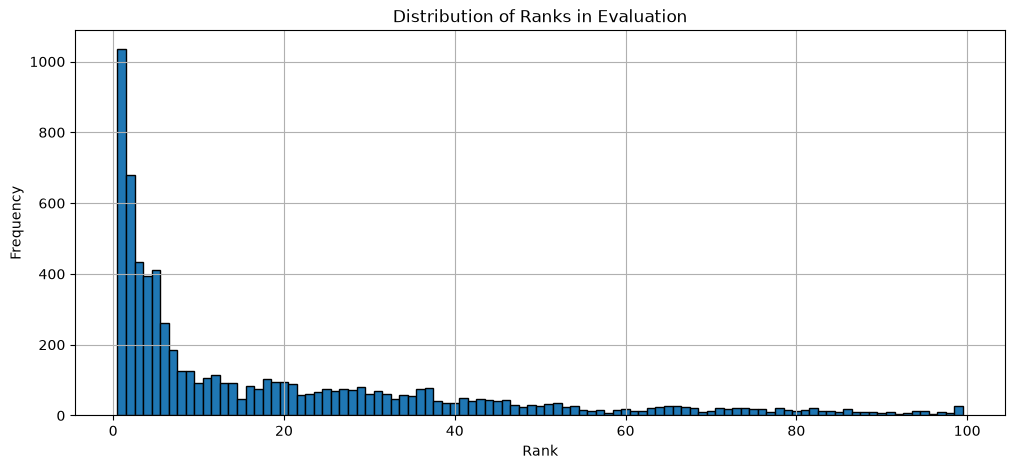

---------------CVE-CWE-----------------
84762


  0%|          | 0/84762 [00:00<?, ?it/s]

Mean Rank: 39.98426181543616
Hits@1: 0.24203062693187985
Hits@3: 0.34864679927325926
Hits@10: 0.6095302140109955
Hits@20: 0.7197446969160709
MRR: 0.34544732763384617


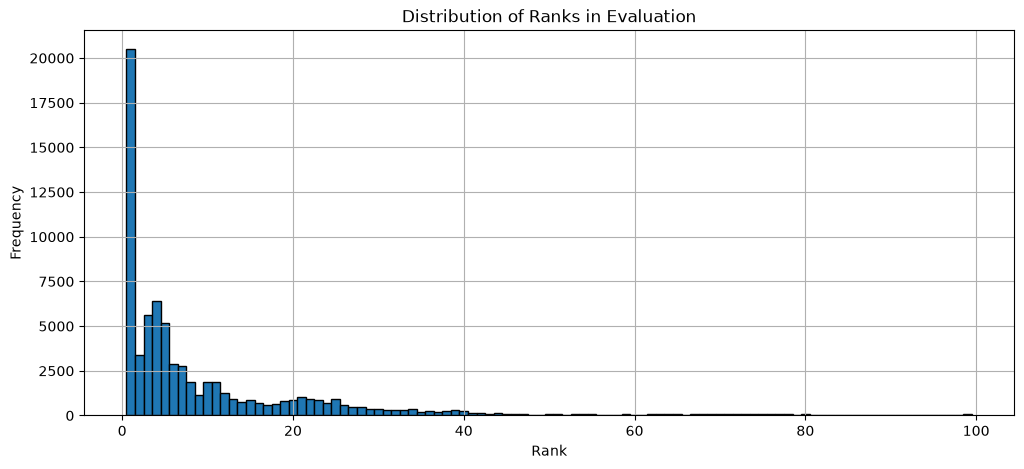

In [57]:
def evaluate_model(model, test_triples, all_entities, known_triples_set, corrupt_side='tail'):
    model.eval()
    ranks = []
    with torch.no_grad():
        for idx in tqdm(range(len(test_triples))):
            h, r, t = test_triples[idx]
            h_id = torch.tensor([h], device=device).long()
            r_id = torch.tensor([r], device=device).long()
            t_id = torch.tensor([t], device=device).long()

            corrupted_entities = []
            for e in all_entities:
                if corrupt_side == 'tail':
                    if e != t:
                        candidate = (h, r, e)
                elif corrupt_side == 'head':  # corrupt head
                    if e != h:
                        candidate = (e, r, t)
                else:
                    continue
                if candidate not in known_triples_set:
                    corrupted_entities.append(e)

            corrupted_entities = torch.tensor(corrupted_entities, device=device).long()

            if corrupt_side == 'tail':
                h_ids = h_id.repeat(len(corrupted_entities))
                r_ids = r_id.repeat(len(corrupted_entities))
                t_ids = corrupted_entities
                true_triple = torch.tensor([[h, r, t]], device=device).long()
            else:
                h_ids = corrupted_entities
                r_ids = r_id.repeat(len(corrupted_entities))
                t_ids = t_id.repeat(len(corrupted_entities))
                true_triple = torch.tensor([[h, r, t]], device=device).long()

            corrupted_triples = torch.stack((h_ids, r_ids, t_ids), dim=1)
            corrupted_scores = model.predict(corrupted_triples)
            true_score = model.predict(true_triple)

            all_scores = torch.cat([true_score, corrupted_scores])
            sorted_scores, indices = torch.sort(all_scores, descending=True)
            rank = (indices == 0).nonzero(as_tuple=True)[0].item() + 1
            ranks.append(rank)
    
    print(f"Mean Rank: {mr_score(ranks)}")
    for k in [1, 3, 10, 20]:
        print(f"Hits@{k}: {hits_at_n(ranks, k)}")
    print(f"MRR: {mrr_score(ranks)}")
    plt.figure(figsize=(12, 5))
    n, bins, patches = plt.hist(ranks, bins=range(1, 101), edgecolor='black', align='left')
    plt.xlabel('Rank')
    plt.ylabel('Frequency')
    plt.title('Distribution of Ranks in Evaluation')
    
    plt.grid(True)
    plt.show()
    return ranks

print("---------------CPE-CVE-----------------")
test_triples = []
for h, r, t in new_test_cpe2cve:
    test_triples.append([entity2id[h], relation2id[r], entity2id[t]])

tails = [entity2id[e] for e in connected_cpelist]
num_test_triples = len(test_triples)
print(num_test_triples)
known_triples_set = set(tuple([h, r, t]) for h, r, t in np.vstack((triples_id, test_triples)))
ranks = evaluate_model(model, test_triples[:num_test_triples], tails, known_triples_set, corrupt_side='head')

print("---------------CVE-CWE-----------------")
test_triples = []
for h, r, t in new_test_cve2cwe:
    test_triples.append([entity2id[h], relation2id[r], entity2id[t]])

tails = [entity2id[e] for e in cwe_list]
num_test_triples = len(test_triples)
print(num_test_triples)
known_triples_set = set(tuple([h, r, t]) for h, r, t in np.vstack((triples_id, test_triples)))
ranks = evaluate_model(model, test_triples[:num_test_triples], tails, known_triples_set, corrupt_side='tail')